Importando bibliotecas e dataset

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data_cts_intentional_homicide.csv", decimal=",")

Separando os países

In [140]:
countries_df = df[df["Country"] != df["Region"]]
countries_df = countries_df[~countries_df["Country"].str.startswith("All ")]
countries_df = countries_df.query("Age == 'Total' & Dimension == 'Total' & Category == 'Total'")

countries_df

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
1308,ABW,Aruba,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,0.000000,MD
1309,AIA,Anguilla,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,0.000000,WHO/NSO/SDG/PAHO
1310,ARM,Armenia,Asia,Western Asia,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,178.000000,UNSDC/TransMonEE/CTS/Covid-19/SDG
1311,ATG,Antigua and Barbuda,Americas,Latin America and the Caribbean,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,1.000000,MD/PAHO/OAS/CTS
1312,AUS,Australia,Oceania,Australia and New Zealand,Victims of intentional homicide,Total,Total,Total,Total,1990,Counts,374.000000,MD/Eurostat/GSH 2019 Revision/CTS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
112243,GRC,Greece,Europe,Southern Europe,Death due to intentional homicide in prison,Total,Total,Total,Total,2021,"Rate per 100,000 population",0.000000,SDG/CTS
112244,LTU,Lithuania,Europe,Northern Europe,Death due to intentional homicide in prison,Total,Total,Total,Total,2021,"Rate per 100,000 population",0.000000,CTS/SDG
112245,MAC,"China, Macao Special Administrative Region",Asia,Eastern Asia,Death due to intentional homicide in prison,Total,Total,Total,Total,2021,"Rate per 100,000 population",0.000000,SDG/CTS
112246,RUS,Russian Federation,Europe,Eastern Europe,Death due to intentional homicide in prison,Total,Total,Total,Total,2021,"Rate per 100,000 population",0.010338,CTS/SDG


Separando as regiões

In [ ]:
regions_df = df[df["Country"] == df["Region"]]
regions_df = regions_df[~regions_df["Country"].str.startswith("All ")]
regions_df = regions_df[regions_df["Country"].ne("World")]
regions_df = regions_df.query("Age == 'Total' & Dimension == 'Total' & Category == 'Total'")
regions_df

,Iso3_code,Country,Region,Subregion,Indicator,Dimension,Category,Sex,Age,Year,Unit of measurement,VALUE,Source
59612,WORLD,World,World,World,Victims of Intentional Homicide - Regional Est...,Total,Total,Total,Total,2000,Counts,424387.104800,UNODC estimate based on national data
59613,WORLD,World,World,World,Victims of Intentional Homicide - Regional Est...,Total,Total,Total,Total,2001,Counts,435484.333900,UNODC estimate based on national data
59614,WORLD,World,World,World,Victims of Intentional Homicide - Regional Est...,Total,Total,Total,Total,2002,Counts,438760.530200,UNODC estimate based on national data
59615,WORLD,World,World,World,Victims of Intentional Homicide - Regional Est...,Total,Total,Total,Total,2003,Counts,432725.973600,UNODC estimate based on national data
59616,WORLD,World,World,World,Victims of Intentional Homicide - Regional Est...,Total,Total,Total,Total,2004,Counts,423863.789900,UNODC estimate based on national data
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113629,M49_W_EUR,Western Europe,Western Europe,Western Europe,Victims of Intentional Homicide - Regional Est...,Total,Total,Male,Total,2017,"Rate per 100,000 population",1.203212,UNODC estimate based on national data
113630,M49_W_EUR,Western Europe,Western Europe,Western Europe,Victims of Intentional Homicide - Regional Est...,Total,Total,Male,Total,2018,"Rate per 100,000 population",1.200968,UNODC estimate based on national data
113631,M49_W_EUR,Western Europe,Western Europe,Western Europe,Victims of Intentional Homicide - Regional Est...,Total,Total,Male,Total,2019,"Rate per 100,000 population",1.107534,UNODC estimate based on national data
113632,M49_W_EUR,Western Europe,Western Europe,Western Europe,Victims of Intentional Homicide - Regional Est...,Total,Total,Male,Total,2020,"Rate per 100,000 population",1.200102,UNODC estimate based on national data


Pergunta 1: Quais países apresentam os 10 maiores índices de homicídios nos últimos 5
anos?

Text(0.5, 1.0, '10 countries with the highest homicide rates in the last 5 years')

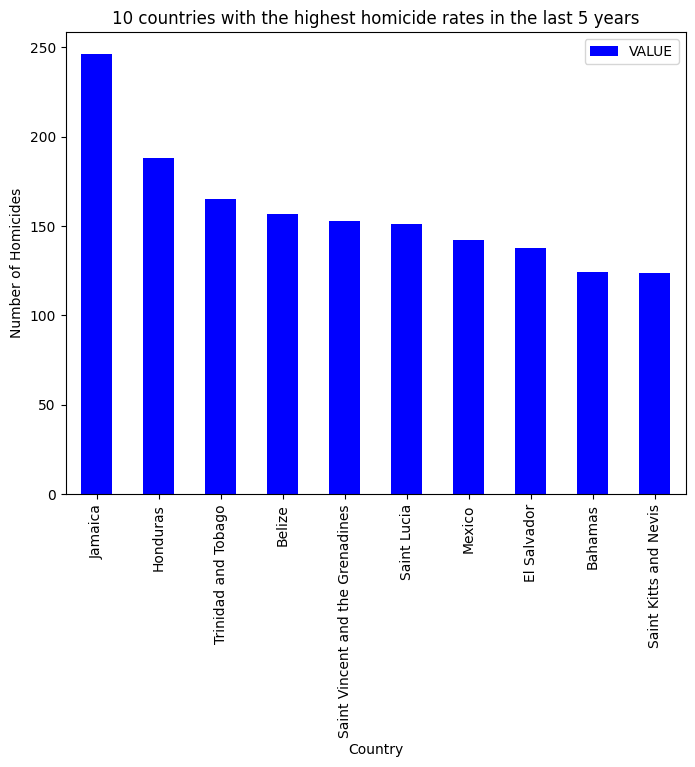

In [142]:
most_homicide_count_in_5_years = countries_df.query("Year >= 2018 & Sex == 'Total'")
most_homicide_count_in_5_years = most_homicide_count_in_5_years[most_homicide_count_in_5_years["Indicator"].eq("Victims of intentional homicide")]
most_homicide_count_in_5_years = most_homicide_count_in_5_years[most_homicide_count_in_5_years["Unit of measurement"].eq("Rate per 100,000 population")]
most_homicide_count_in_5_years = most_homicide_count_in_5_years.groupby("Country", as_index=False)["VALUE"].sum().sort_values(by="VALUE", ascending=False)
most_homicide_count_in_5_years.head(10).plot(
    x = "Country",
    y = "VALUE",
    kind = "bar",
    figsize = (8,6),
    color = "blue"
)
plt.ylabel("Number of Homicides")
plt.title("10 countries with the highest homicide rates in the last 5 years")


Pergunta 2: Quais países apresentam os 10 maiores índices de homicídios de mulheres em
2022?

Text(0.5, 1.0, '10 countries with the highest rates of female mortality')

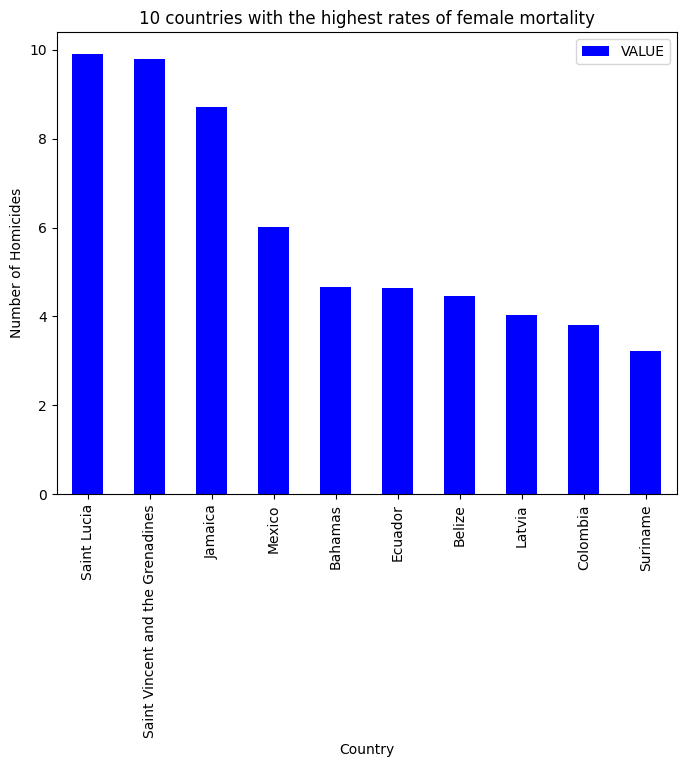

In [143]:
most_female_homicides_2022 = countries_df.query("Year == 2022 & Sex == 'Female'")
most_female_homicides_2022 = most_female_homicides_2022[most_female_homicides_2022["Indicator"].eq("Victims of intentional homicide")]
most_female_homicides_2022 = most_female_homicides_2022[most_female_homicides_2022["Unit of measurement"].eq("Rate per 100,000 population")]
most_female_homicides_2022 = most_female_homicides_2022.groupby("Country", as_index=False)["VALUE"].sum()
most_female_homicides_2022 = most_female_homicides_2022.sort_values(by="VALUE", ascending=False)
most_female_homicides_2022.head(10).plot(
    x = "Country",
    y = "VALUE",
    kind = "bar",
    figsize = (8,6),
    color = "blue"
)
plt.ylabel("Number of Homicides")
plt.title("10 countries with the highest rates of female mortality")

Pergunta 3: Quais as regiões com mais homicídios?

Text(0.5, 1.0, 'Regions with the highest homicide rates')

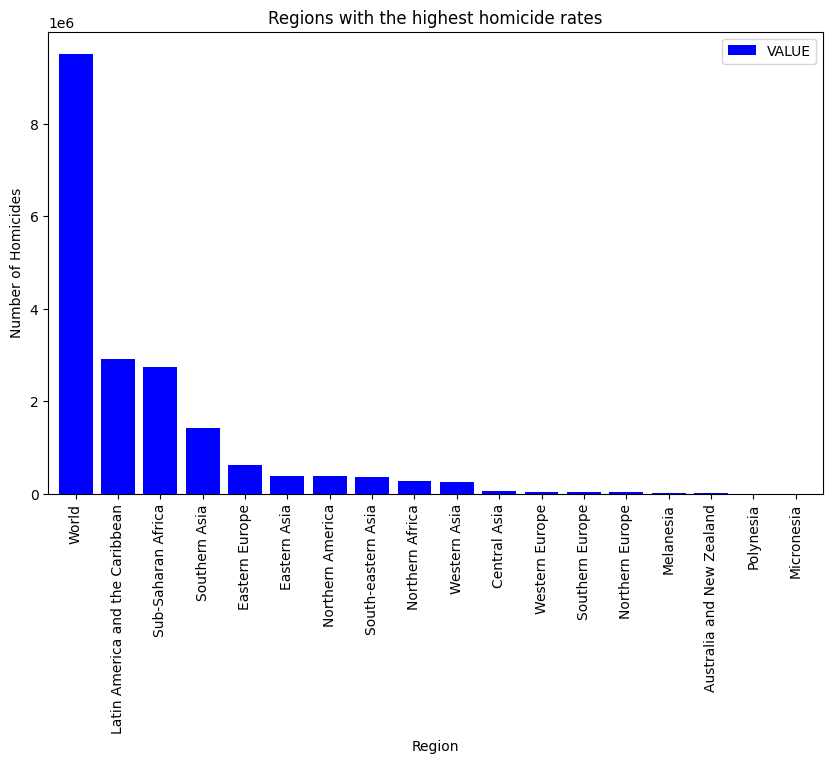

In [144]:
regions_with_most_homicides = regions_df.query("Sex == 'Total'")
regions_with_most_homicides = regions_with_most_homicides[regions_with_most_homicides["Indicator"].str.startswith("Victims")]
regions_with_most_homicides = regions_with_most_homicides[regions_with_most_homicides["Unit of measurement"].eq("Counts")]
regions_with_most_homicides = regions_with_most_homicides.groupby("Region", as_index=False)["VALUE"].sum()
regions_with_most_homicides = regions_with_most_homicides.sort_values(by="VALUE", ascending=False)

regions_with_most_homicides.plot(
    x = "Region",
    y = "VALUE",
    kind = "bar",
    figsize = (10,6),
    color = "blue",
    width = 0.8
)

plt.ylabel("Number of Homicides")
plt.title("Regions with the highest homicide rates")

Pergunta 4: Quais países com menor número de homicídios em cada subregião?

Text(0.5, 1.0, 'Countries with the lowest number of homicides by sub-region')

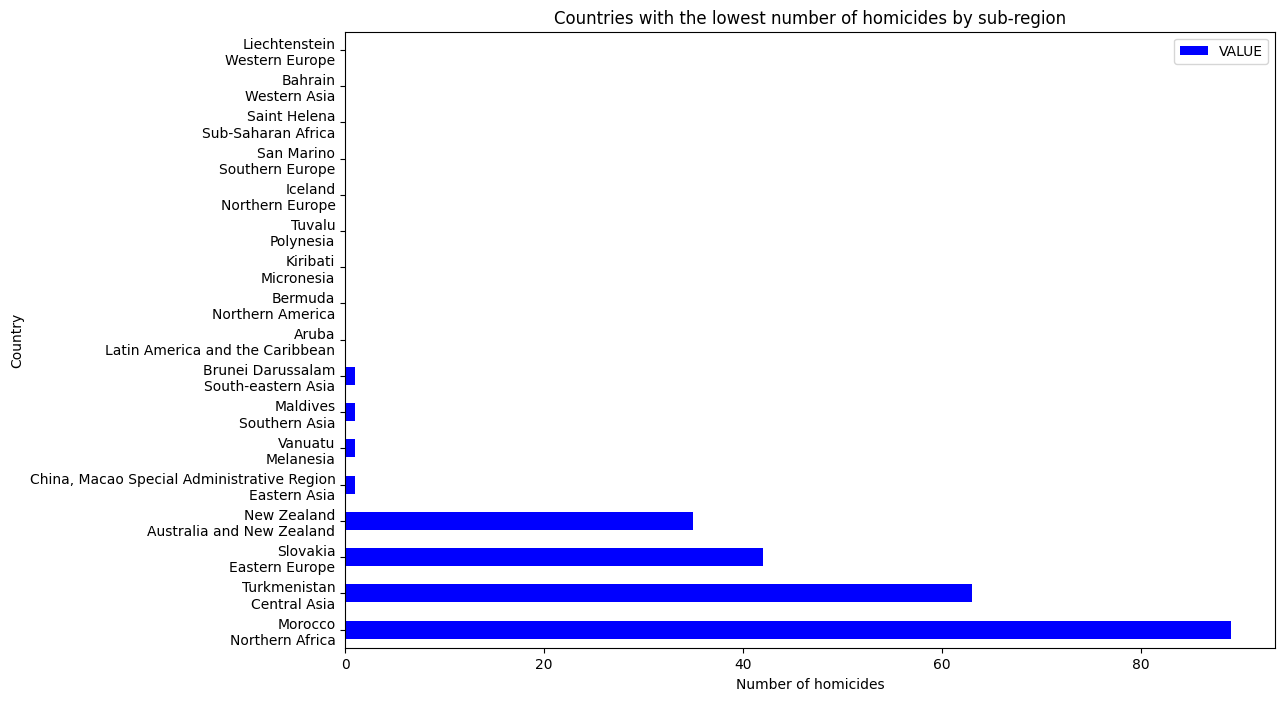

In [145]:
least_homicides_by_subregion = countries_df.query("Sex == 'Total'")
least_homicides_by_subregion = least_homicides_by_subregion[least_homicides_by_subregion["Indicator"].eq("Victims of intentional homicide")]
least_homicides_by_subregion = least_homicides_by_subregion[least_homicides_by_subregion["Unit of measurement"].eq("Counts")]
idx = least_homicides_by_subregion.groupby("Subregion")["VALUE"].idxmin()
least_homicides_by_subregion = least_homicides_by_subregion.loc[idx, ["Subregion", "Country", "VALUE"]]
least_homicides_by_subregion = least_homicides_by_subregion.sort_values(by="VALUE", ascending=False)

least_homicides_by_subregion["Label"] = (
    least_homicides_by_subregion["Country"]
    + "\n"
    + least_homicides_by_subregion["Subregion"]
)

least_homicides_by_subregion = (
    least_homicides_by_subregion
    .sort_values("VALUE", ascending=False)
)

least_homicides_by_subregion.plot(
    x = "Label",
    y = "VALUE",
    kind = "barh",
    figsize= (12,8),
    color = "blue",
    width = 0.5
)
plt.ylabel("Country")
plt.xlabel("Number of homicides")
plt.title("Countries with the lowest number of homicides by sub-region")

Pergunta 5: Quais países com menor número de morte de mulheres?

Text(0.5, 1.0, 'Countries with the lowest number of female deaths')

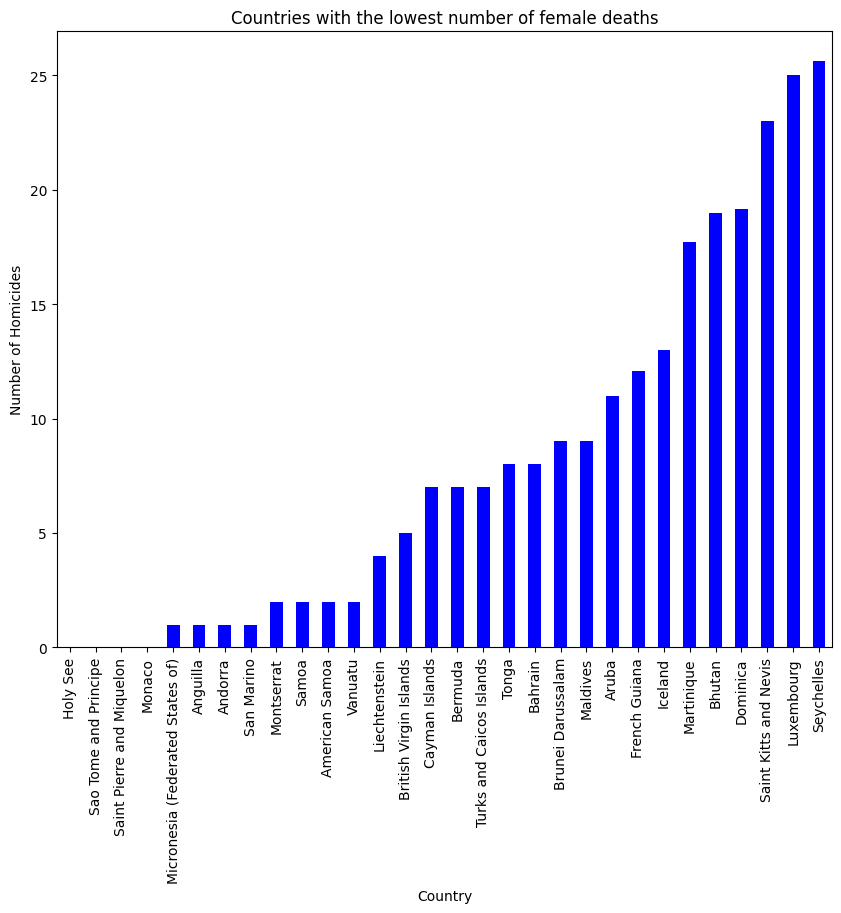

In [154]:
least_female_homicides = countries_df.query("Sex == 'Female'")
least_female_homicides = least_female_homicides[least_female_homicides["Indicator"].eq("Victims of intentional homicide")]
least_female_homicides = least_female_homicides[least_female_homicides["Unit of measurement"].eq("Counts")]
least_female_homicides = least_female_homicides.groupby("Country", as_index=False)["VALUE"].sum()
least_female_homicides = least_female_homicides.sort_values(by="VALUE", ascending=True)
least_female_homicides

least_female_homicides.head(30).plot(
    x = "Country",
    y = "VALUE",
    kind = "bar",
    figsize = (10,8),
    color = "blue"
)

plt.legend().remove()
plt.ylabel("Number of Homicides")
plt.title("Countries with the lowest number of female deaths")

Pergunta 6: Quais as subregiões com maior número de homicídios?

Text(0.5, 1.0, 'Subregions with the highest homicide rates')

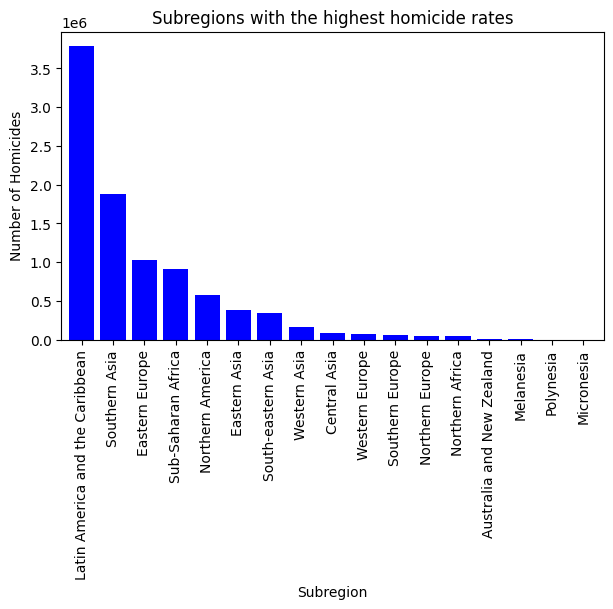

In [147]:
most_homicides_subregion = countries_df.query("Sex == 'Total'")
most_homicides_subregion = most_homicides_subregion[most_homicides_subregion["Indicator"].eq("Victims of intentional homicide")]
most_homicides_subregion = most_homicides_subregion[most_homicides_subregion["Unit of measurement"].eq("Counts")]
most_homicides_subregion = most_homicides_subregion.groupby("Subregion", as_index=False)["VALUE"].sum()
most_homicides_subregion = most_homicides_subregion.sort_values(by="VALUE", ascending=False)
most_homicides_subregion

most_homicides_subregion.plot(
    x = "Subregion",
    y = "VALUE",
    kind = "bar",
    figsize = (7,4),
    width = 0.8,
    color = "blue"
)

plt.ylabel("Number of Homicides")
plt.legend().remove()
plt.title("Subregions with the highest homicide rates")

Pergunta 7:  Identifique o país com maior número de homicídios em cada continente em
2020

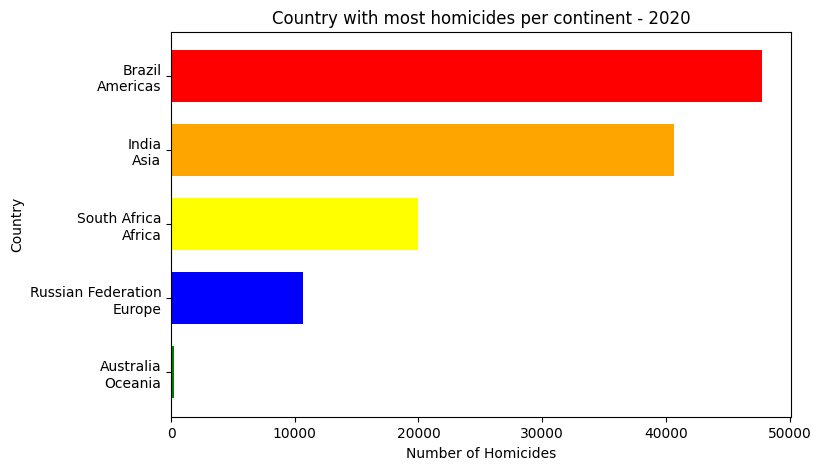

In [148]:

most_homicides_by_continent = countries_df.query("Year == 2020 & Sex == 'Total'")
most_homicides_by_continent = most_homicides_by_continent[most_homicides_by_continent["Indicator"].eq("Victims of intentional homicide")]
most_homicides_by_continent = most_homicides_by_continent[most_homicides_by_continent["Unit of measurement"].eq("Counts")]
idx = most_homicides_by_continent.groupby("Region")["VALUE"].idxmax()
most_homicides_by_continent = most_homicides_by_continent.loc[idx, ["Region", "Country", "VALUE"]]
most_homicides_by_continent.rename(columns={"Region": "Continent"}, inplace=True)
most_homicides_by_continent = most_homicides_by_continent.sort_values(by="VALUE", ascending=False)

most_homicides_by_continent["Label"] = (
    most_homicides_by_continent["Country"]
    + "\n"
    + most_homicides_by_continent["Continent"]
)
most_homicides_by_continent = (
    most_homicides_by_continent
    .sort_values("VALUE", ascending=True)
)


most_homicides_by_continent.plot(
    x = "Label",
    y = "VALUE",
    kind = "barh",
    figsize=(8,5),
    color = ["green","blue","yellow", "orange","red"],
    width = 0.7
)
plt.xlabel("Number of Homicides")
plt.ylabel("Country")
plt.title("Country with most homicides per continent - 2020")
plt.legend().remove()


Pergunta 8: Qual o país mais violento para as mulheres em 2021?

In [62]:
most_female_homicides_2021 = countries_df.query("Year == 2021 & Sex == 'Female'")
most_female_homicides_2021 = most_female_homicides_2021[most_female_homicides_2021["Indicator"].eq("Victims of intentional homicide")]
most_female_homicides_2021 = most_female_homicides_2021[most_female_homicides_2021["Unit of measurement"].eq("Rate per 100,000 population")]
most_female_homicides_2021 = most_female_homicides_2021.sort_values(by="VALUE", ascending=False)
most_female_homicides_2021[["Country", "VALUE"]].head(1)

,Country,VALUE
70292,Antigua and Barbuda,10.265149


Pergunta 9: Qual o país com maior valor de 'indicador: Victims of intentional homicide'?

In [63]:
most_victims_of_intentional_homicide = countries_df.query("Sex == 'Total'")
most_victims_of_intentional_homicide = most_victims_of_intentional_homicide[most_victims_of_intentional_homicide["Indicator"].eq("Victims of intentional homicide")]
most_victims_of_intentional_homicide = most_victims_of_intentional_homicide[most_victims_of_intentional_homicide["Unit of measurement"].eq("Counts")]
most_victims_of_intentional_homicide = most_victims_of_intentional_homicide.sort_values(by="VALUE", ascending=False)
most_victims_of_intentional_homicide[["Country", "VALUE"]].head(1)

,Country,VALUE
4765,Brazil,63788.0


Pergunta 10: Qual a média de homicídios no Brasil nos últimos 10 anos?

In [64]:
brasil_homicides_mean = countries_df.query("Sex == 'Total' & Country == 'Brazil' & Year >= 2012")
brasil_homicides_mean = brasil_homicides_mean[brasil_homicides_mean["Indicator"].eq("Victims of intentional homicide")]
brasil_homicides_mean = brasil_homicides_mean[brasil_homicides_mean["Unit of measurement"].eq("Counts")]
brasil_homicides_mean = brasil_homicides_mean.groupby("Country", as_index=False)["VALUE"].mean()
brasil_homicides_mean = brasil_homicides_mean.sort_values(by="VALUE", ascending=False)
brasil_homicides_mean

,Country,VALUE
0,Brazil,54948.3
